# CSE284 Final Project - Comparing Global Ancestry Analysis Methods on 1000 Genomes Phase 3 Data

In [1]:
from pathlib import Path
import os

candidate = Path.cwd()
repo_root = None
for path in [candidate, *candidate.parents]:
    if (path / "admixture.sh").exists() and (path / "structure.sh").exists():
        repo_root = path
        break

if repo_root is None:
    raise FileNotFoundError("Cannot locate repo root containing admixture.sh and structure.sh")

os.chdir(repo_root)
print("Current working directory:", os.getcwd())

Current working directory: /home/wjl/Population_Structure_Modeling


## Data Exploration

In [2]:
from pathlib import Path
import pandas as pd

repo = Path.cwd()
print(f"Repo root: {repo}")

# 1) Sample metadata (1000 Genomes)
igsr_path = repo / "1000Genomes/igsr_samples.tsv"
igsr_df = pd.read_csv(igsr_path, sep="\t")
print("\n[igsr_samples.tsv]")
print("shape:", igsr_df.shape)
print("columns:", list(igsr_df.columns))
print("dtypes (first 10):")
print(igsr_df.dtypes.head(10))
print("\nhead:")
display(igsr_df.head(3))

Repo root: /home/wjl/Population_Structure_Modeling

[igsr_samples.tsv]
shape: (4978, 9)
columns: ['Sample name', 'Sex', 'Biosample ID', 'Population code', 'Population name', 'Superpopulation code', 'Superpopulation name', 'Population elastic ID', 'Data collections']
dtypes (first 10):
Sample name              object
Sex                      object
Biosample ID             object
Population code          object
Population name          object
Superpopulation code     object
Superpopulation name     object
Population elastic ID    object
Data collections         object
dtype: object

head:


,Sample name,Sex,Biosample ID,Population code,Population name,Superpopulation code,Superpopulation name,Population elastic ID,Data collections
0,HG00271,male,SAME123417,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
1,HG00276,female,SAME123424,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,HG00288,female,SAME1839246,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."


## Data Preprocessing

In [3]:
from pathlib import Path
import shlex
import subprocess


def run_preprocess_if_needed(
    out_dir: str,
    prefix: str,
    extra_args: list[str] | None = None,
    force: bool = False,
    run_chr_process: bool = False,
) -> None:
    fam_path = Path(out_dir) / f"{prefix}_ALL.pruned.fam"
    if fam_path.exists() and not force:
        print(f"Found {fam_path}, skip preprocess.")
        return

    cmd = [
        "bash", "preprocess.sh",
        "--out-dir", out_dir,
        "--prefix", prefix,
        "--sample-info", "1000Genomes/igsr_samples.tsv",
        "--chr-start", "1",
        "--chr-end", "22",
    ]
    if run_chr_process:
        cmd.append("--run-chr-process")
    if extra_args:
        cmd.extend(extra_args)

    print("Running:", shlex.join(cmd))
    subprocess.run(cmd, check=True)


run_preprocess_if_needed(
    out_dir="dump/admixture",
    prefix="admixture",
    force=False,
    run_chr_process=False,
)


Found dump/admixture/admixture_ALL.pruned.fam, skip preprocess.


In [4]:
run_preprocess_if_needed(
    out_dir="dump/structure",
    prefix="structure",
    force=False,
    run_chr_process=False,
)


Found dump/structure/structure_ALL.pruned.fam, skip preprocess.


In [5]:

# Generate per-individual population file for structure_threader (--ind format)
# Format: SampleName \t PopCode \t DisplayOrder (no header, one row per individual)

import pandas as pd

igsr = pd.read_csv("1000Genomes/igsr_samples.tsv", sep="\t")
phase3 = igsr[igsr["Data collections"].str.contains("1000 Genomes phase 3 release", case=False, na=False)]
sample_to_pop = dict(zip(phase3["Sample name"], phase3["Population code"]))

fam = pd.read_csv(
    "dump/structure/structure_ALL.pruned.fam",
    sep=r"\s+",
    header=None,
    names=["FID", "IID", "PID", "MID", "SEX", "PHENO"],
    dtype=str,
)

# Sanity check: --double-id in plink guarantees FID == IID
assert (fam["FID"] == fam["IID"]).all(), "FID != IID: --double-id may not have been used during preprocessing"

fam["pop"] = fam["IID"].map(sample_to_pop)

pop_order = sorted(fam["pop"].dropna().unique())
pop_to_order = {p: i + 1 for i, p in enumerate(pop_order)}
fam["order"] = fam["pop"].map(pop_to_order)

fam[["IID", "pop", "order"]].to_csv(
    "dump/structure/structure_ind_file.tsv",
    sep="\t",
    header=False,
    index=False,
)

print(f"Ind file written: {len(fam)} individuals, {len(pop_order)} populations, missing_pop={fam['pop'].isna().sum()}")


Ind file written: 2504 individuals, 27 populations, missing_pop=0


## Run Experiments Using Bash Files

In [4]:
!bash admixture.sh

Creating merge list...
PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to dump/admixture/admixture_ALL.pruned.log.
Options in effect:
  --bfile dump/admixture/admixture_chr1.pruned
  --make-bed
  --merge-list dump/admixture/mergelist.txt
  --out dump/admixture/admixture_ALL.pruned

15544 MB RAM detected; reserving 7772 MB for main workspace.
Performing single-pass merge (2504 people, 95251 variants).
Merged fileset written to dump/admixture/admixture_ALL.pruned-merge.bed +
dump/admixture/admixture_ALL.pruned-merge.bim +
dump/admixture/admixture_ALL.pruned-merge.fam .
95251 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to dump/admixture/admixture_ALL.pruned.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2504 founders and 0 nonfounders present.
Calc

In [5]:
!bash structure.sh

Creating merge list...
PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to dump/structure/structure_ALL.pruned.log.
Options in effect:
  --bfile dump/structure/structure_chr1.pruned
  --make-bed
  --merge-list dump/structure/mergelist.txt
  --out dump/structure/structure_ALL.pruned

15544 MB RAM detected; reserving 7772 MB for main workspace.
Performing single-pass merge (2504 people, 95251 variants).
Merged fileset written to dump/structure/structure_ALL.pruned-merge.bed +
dump/structure/structure_ALL.pruned-merge.bim +
dump/structure/structure_ALL.pruned-merge.fam .
95251 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to dump/structure/structure_ALL.pruned.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2504 founders and 0 nonfounders present.
Calc

### Post-Experiment Output Sanity Checks

In [6]:
from pathlib import Path
import re
import pandas as pd

repo = Path.cwd()

# 0) PLINK FAM/BIM checks (generated by preprocess in experiment scripts)
fam_path = repo / "dump/admixture/admixture_ALL.pruned.fam"
fam_cols = ["FID", "IID", "PID", "MID", "SEX", "PHENO"]
fam_df = pd.read_csv(fam_path, sep=r"\s+", header=None, names=fam_cols)
print("[admixture_ALL.pruned.fam]")
print("shape:", fam_df.shape)
display(fam_df.head(3))

bim_path = repo / "dump/admixture/admixture_ALL.pruned.bim"
bim_cols = ["CHR", "SNP", "CM", "BP", "A1", "A2"]
bim_df = pd.read_csv(bim_path, sep=r"\s+", header=None, names=bim_cols)
print("\n[admixture_ALL.pruned.bim]")
print("shape:", bim_df.shape)
display(bim_df.head(3))

# 1) ADMIXTURE Q files: K, rows, columns
print("\n[ADMIXTURE Q files]")
q_files = sorted((repo / "dump/admixture").glob("admixture_ALL.pruned.*.Q"))
q_summary = []
for qf in q_files:
    m = re.search(r"\.([0-9]+)\.Q$", qf.name)
    if not m:
        continue
    k = int(m.group(1))
    q_df = pd.read_csv(qf, sep=r"\s+", header=None)
    q_summary.append({
        "file": qf.name,
        "K": k,
        "n_samples": q_df.shape[0],
        "n_components": q_df.shape[1],
        "matches_fam_rows": q_df.shape[0] == fam_df.shape[0],
    })

q_summary_df = pd.DataFrame(q_summary).sort_values("K")
display(q_summary_df)

# 2) fastSTRUCTURE meanQ files: K, rows, columns
print("\n[fastSTRUCTURE meanQ files]")
meanq_dir = repo / "dump/structure/structure_ALL"
meanq_files = sorted(meanq_dir.glob("fS_run_K.*.meanQ"))
meanq_summary = []
for mf in meanq_files:
    m = re.search(r"K\.([0-9]+)\.meanQ$", mf.name)
    if not m:
        continue
    k = int(m.group(1))
    m_df = pd.read_csv(mf, sep=r"\s+", header=None)
    meanq_summary.append({
        "file": mf.name,
        "K": k,
        "n_samples": m_df.shape[0],
        "n_components": m_df.shape[1],
        "matches_fam_rows": m_df.shape[0] == fam_df.shape[0],
    })

meanq_summary_df = pd.DataFrame(meanq_summary).sort_values("K")
display(meanq_summary_df)

[admixture_ALL.pruned.fam]
shape: (2504, 6)


,FID,IID,PID,MID,SEX,PHENO
0,HG00096,HG00096,0,0,0,-9
1,HG00097,HG00097,0,0,0,-9
2,HG00099,HG00099,0,0,0,-9



[admixture_ALL.pruned.bim]
shape: (95251, 6)


,CHR,SNP,CM,BP,A1,A2
0,1,rs12124819,0,776546,G,A
1,1,rs1110052,0,873558,T,G
2,1,rs9697457,0,934345,A,G



[ADMIXTURE Q files]


,file,K,n_samples,n_components,matches_fam_rows
1,admixture_ALL.pruned.2.Q,2,2504,2,True
2,admixture_ALL.pruned.3.Q,3,2504,3,True
3,admixture_ALL.pruned.4.Q,4,2504,4,True
4,admixture_ALL.pruned.5.Q,5,2504,5,True
5,admixture_ALL.pruned.6.Q,6,2504,6,True
6,admixture_ALL.pruned.7.Q,7,2504,7,True
7,admixture_ALL.pruned.8.Q,8,2504,8,True
8,admixture_ALL.pruned.9.Q,9,2504,9,True
0,admixture_ALL.pruned.10.Q,10,2504,10,True



[fastSTRUCTURE meanQ files]


,file,K,n_samples,n_components,matches_fam_rows
1,fS_run_K.2.meanQ,2,2504,2,True
2,fS_run_K.3.meanQ,3,2504,3,True
3,fS_run_K.4.meanQ,4,2504,4,True
4,fS_run_K.5.meanQ,5,2504,5,True
5,fS_run_K.6.meanQ,6,2504,6,True
6,fS_run_K.7.meanQ,7,2504,7,True
7,fS_run_K.8.meanQ,8,2504,8,True
8,fS_run_K.9.meanQ,9,2504,9,True
0,fS_run_K.10.meanQ,10,2504,10,True


In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score,
)

repo = Path.cwd()
EPS = 1e-12
SUPER_POPS = ["AFR", "AMR", "EAS", "EUR", "SAS"]

def load_q_matrix(path):
    q = pd.read_csv(path, sep=r"\s+", header=None).to_numpy(dtype=float)
    q = np.clip(q, EPS, None)
    q /= q.sum(axis=1, keepdims=True)
    return q


def load_iids_from_fam(path):
    fam = pd.read_csv(path, sep=r"\s+", header=None, usecols=[1], names=["IID"], dtype=str)
    return fam["IID"].tolist()


adm_q_files = sorted((repo / "dump/admixture").glob("admixture_ALL.pruned.*.Q"))
fst_q_files = sorted((repo / "dump/structure/structure_ALL").glob("fS_run_K.*.meanQ"))

adm_map = {int(re.search(r"\.([0-9]+)\.Q$", p.name).group(1)): p for p in adm_q_files}
fst_map = {int(re.search(r"K\.([0-9]+)\.meanQ$", p.name).group(1)): p for p in fst_q_files}
K_common = sorted(set(adm_map) & set(fst_map))

# Align samples between the two methods
adm_iids = load_iids_from_fam(repo / "dump/admixture/admixture_ALL.pruned.fam")
fst_iids = load_iids_from_fam(repo / "dump/structure/structure_ALL.pruned.fam")
fst_idx = {iid: i for i, iid in enumerate(fst_iids)}
common_iids = [iid for iid in adm_iids if iid in fst_idx]
adm_order = [adm_iids.index(iid) for iid in common_iids]
fst_order = [fst_idx[iid] for iid in common_iids]

adm_Q = {k: load_q_matrix(adm_map[k])[adm_order] for k in K_common}
fst_Q = {k: load_q_matrix(fst_map[k])[fst_order] for k in K_common}

igsr = pd.read_csv(repo / "1000Genomes/igsr_samples.tsv", sep="\t")
sample_col = "Sample name" if "Sample name" in igsr.columns else "Sample"
superpop_col = next(
    c for c in ["Superpopulation code", "Superpopulation", "Super Population"]
    if c in igsr.columns
)
sample_to_superpop = dict(zip(igsr[sample_col].astype(str), igsr[superpop_col].astype(str)))
superpops = [sample_to_superpop.get(iid, np.nan) for iid in common_iids]

print(f"Common K values: {K_common}")
print(f"Common samples:  {len(common_iids)}")
print(f"Labeled samples: {sum(pd.notna(s) for s in superpops)}")

Common K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Common samples:  2504
Labeled samples: 2504


## Quantitative Comparison on Time and Space Complexity

,time_ratio_fastSTRUCTURE_over_ADMIXTURE,memory_ratio_fastSTRUCTURE_over_ADMIXTURE
K_num,,
2,1.344,0.607
3,2.496,0.618
4,2.469,0.639
5,2.798,0.646
6,3.234,0.666
7,3.349,0.670
8,2.943,0.701
9,1.882,0.704
10,2.135,0.705



[Fit-step summary by method]


,runs,k_min,k_max,elapsed_mean_sec,elapsed_sum_sec,rss_mean_mb,rss_peak_mb,cpu_eff_mean
method_label,,,,,,,,
ADMIXTURE,9,2,10,810.444,7294,589.948,673.488,9.292
fastSTRUCTURE,9,2,10,2114.333,19029,392.403,474.645,1.003



[Per-K detailed table]


,method_label,K_num,elapsed_sec,max_rss_mb,total_cpu_sec,cpu_efficiency
1,ADMIXTURE,2,186,505.102,1545.74,8.310
11,fastSTRUCTURE,2,250,306.711,253.66,1.015
2,ADMIXTURE,3,262,526.438,2310.11,8.817
12,fastSTRUCTURE,3,654,325.586,656.83,1.004
3,ADMIXTURE,4,473,546.426,4365.25,9.229
13,fastSTRUCTURE,4,1168,349.375,1171.38,1.003
4,ADMIXTURE,5,506,569.402,4672.50,9.234
14,fastSTRUCTURE,5,1416,367.867,1418.90,1.002
5,ADMIXTURE,6,858,591.387,8173.73,9.526
15,fastSTRUCTURE,6,2775,393.770,2777.59,1.001


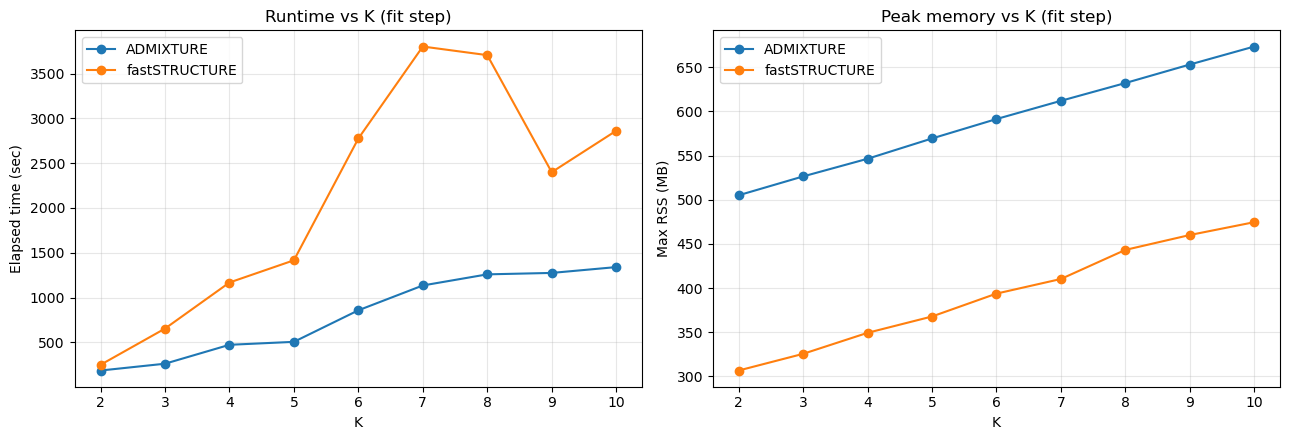

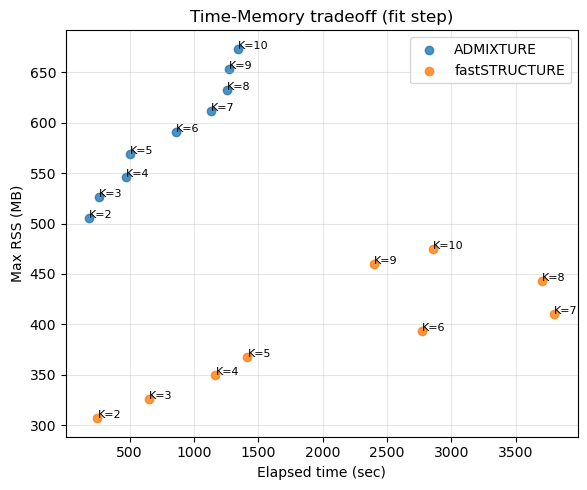

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

repo = Path.cwd()
adm_metrics_path = repo / "dump/admixture/metrics.tsv"
fst_metrics_path = repo / "dump/structure/metrics.tsv"

adm = pd.read_csv(adm_metrics_path, sep="\t")
fst = pd.read_csv(fst_metrics_path, sep="\t")

metrics = pd.concat([adm, fst], ignore_index=True)

# Keep successful runs only
metrics = metrics[metrics["exit_code"] == 0].copy()

# Numeric conversion (NA -> NaN)
for col in ["elapsed_sec", "user_cpu_sec", "sys_cpu_sec", "max_rss_kb"]:
    metrics[col] = pd.to_numeric(metrics[col], errors="coerce")

# Keep fit step with valid numeric K for method-to-method comparison
fit = metrics[(metrics["step"] == "fit")].copy()
fit["K_num"] = pd.to_numeric(fit["K"], errors="coerce")
fit = fit.dropna(subset=["K_num"])
fit["K_num"] = fit["K_num"].astype(int)

# Method naming for plotting
method_map = {"admixture": "ADMIXTURE", "faststructure": "fastSTRUCTURE"}
fit["method_label"] = fit["method"].map(method_map).fillna(fit["method"])

fit["total_cpu_sec"] = fit["user_cpu_sec"].fillna(0) + fit["sys_cpu_sec"].fillna(0)
fit["cpu_efficiency"] = fit["total_cpu_sec"] / fit["elapsed_sec"].replace(0, np.nan)
fit["max_rss_mb"] = fit["max_rss_kb"] / 1024

# Wide table for side-by-side comparison
pivot = fit.pivot_table(
    index="K_num",
    columns="method_label",
    values=["elapsed_sec", "max_rss_mb", "cpu_efficiency"],
    aggfunc="mean",
)

# Add relative metrics (fastSTRUCTURE / ADMIXTURE) where both exist
if {"ADMIXTURE", "fastSTRUCTURE"}.issubset(pivot["elapsed_sec"].columns):
    time_ratio = pivot[("elapsed_sec", "fastSTRUCTURE")] / pivot[("elapsed_sec", "ADMIXTURE")]
    mem_ratio = pivot[("max_rss_mb", "fastSTRUCTURE")] / pivot[("max_rss_mb", "ADMIXTURE")]
    ratio_df = pd.DataFrame({
        "time_ratio_fastSTRUCTURE_over_ADMIXTURE": time_ratio,
        "memory_ratio_fastSTRUCTURE_over_ADMIXTURE": mem_ratio,
    })
    display(ratio_df.round(3))

print("\n[Fit-step summary by method]")
summary = fit.groupby("method_label").agg(
    runs=("K_num", "count"),
    k_min=("K_num", "min"),
    k_max=("K_num", "max"),
    elapsed_mean_sec=("elapsed_sec", "mean"),
    elapsed_sum_sec=("elapsed_sec", "sum"),
    rss_mean_mb=("max_rss_mb", "mean"),
    rss_peak_mb=("max_rss_mb", "max"),
    cpu_eff_mean=("cpu_efficiency", "mean"),
).round(3)
display(summary)

print("\n[Per-K detailed table]")
detail = fit[["method_label", "K_num", "elapsed_sec", "max_rss_mb", "total_cpu_sec", "cpu_efficiency"]].sort_values(["K_num", "method_label"])
display(detail.round(3))

# ---------- Visualization ----------
# Line plots: over K
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method_label, g in fit.groupby("method_label"):
    g = g.sort_values("K_num")
    axes[0].plot(g["K_num"], g["elapsed_sec"], marker="o", label=method_label)
    axes[1].plot(g["K_num"], g["max_rss_mb"], marker="o", label=method_label)

axes[0].set_title("Runtime vs K (fit step)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Elapsed time (sec)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Peak memory vs K (fit step)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Max RSS (MB)")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

# #  Barplot
# k_values = sorted(fit["K_num"].unique())
# methods = [m for m in ["ADMIXTURE", "fastSTRUCTURE"] if m in fit["method_label"].unique()]
# x = np.arange(len(k_values))
# width = 0.35

# fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# for idx, m in enumerate(methods):
#     g = fit[fit["method_label"] == m].set_index("K_num").reindex(k_values)
#     offset = (idx - (len(methods)-1)/2) * width
#     axes[0].bar(x + offset, g["elapsed_sec"], width=width, label=m)
#     axes[1].bar(x + offset, g["max_rss_mb"], width=width, label=m)

# axes[0].set_xticks(x, k_values)
# axes[0].set_title("Runtime per K (bar)")
# axes[0].set_xlabel("K")
# axes[0].set_ylabel("Elapsed time (sec)")
# axes[0].grid(axis="y", alpha=0.3)

# axes[1].set_xticks(x, k_values)
# axes[1].set_title("Peak memory per K (bar)")
# axes[1].set_xlabel("K")
# axes[1].set_ylabel("Max RSS (MB)")
# axes[1].grid(axis="y", alpha=0.3)

# for ax in axes:
#     ax.legend()
# plt.tight_layout()
# plt.show()

# Scatter for time-memory tradeoff
plt.figure(figsize=(6, 5))
for method_label, g in fit.groupby("method_label"):
    plt.scatter(g["elapsed_sec"], g["max_rss_mb"], label=method_label, alpha=0.8)
    for _, row in g.iterrows():
        plt.text(row["elapsed_sec"], row["max_rss_mb"], f"K={row['K_num']}", fontsize=8)

plt.title("Time-Memory tradeoff (fit step)")
plt.xlabel("Elapsed time (sec)")
plt.ylabel("Max RSS (MB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Qualitative Comparison on Global Ancestry Inference Results

### Visulization of Population Structure

You can run our analysis code below to observe something interesting when exploring population structure.

**High-Level Consistency**: Both models successfully identify the major continental clusters that correspond to the 1000 Genomes Project populations. Even as $K$ increases, the "backbone" of the population structure remains stable. For instance, European (EUR) groups such as CEU, GBR, and IBS show high consistency, while ASW and ACB (African Americans/Caribbeans) exhibit complex admixture patterns.

**fastSTRUCTURE with less noise**: fastSTRUCTURE tends to produce **cleaner** looking plots with less background noise. This is because its underlying variational Bayesian framework often forces individuals toward 0 or 1 membership unless there is strong evidence for admixture. In contrast, Admixture model appears more sensitive to subtle gene flow. You can see more **noise** or low-level components across almost all individuals, which often reflects actual historical interbreeding rather than just mathematical artifacts.

**The "Splitter" Effect**: As you move from $K=4$ to $K=8$, you can observe how a single ancestral component in one population (e.g., YRI group) begins to fragment into two distinct sub-components, indicating finer-scale sub-structure within that geographic region.

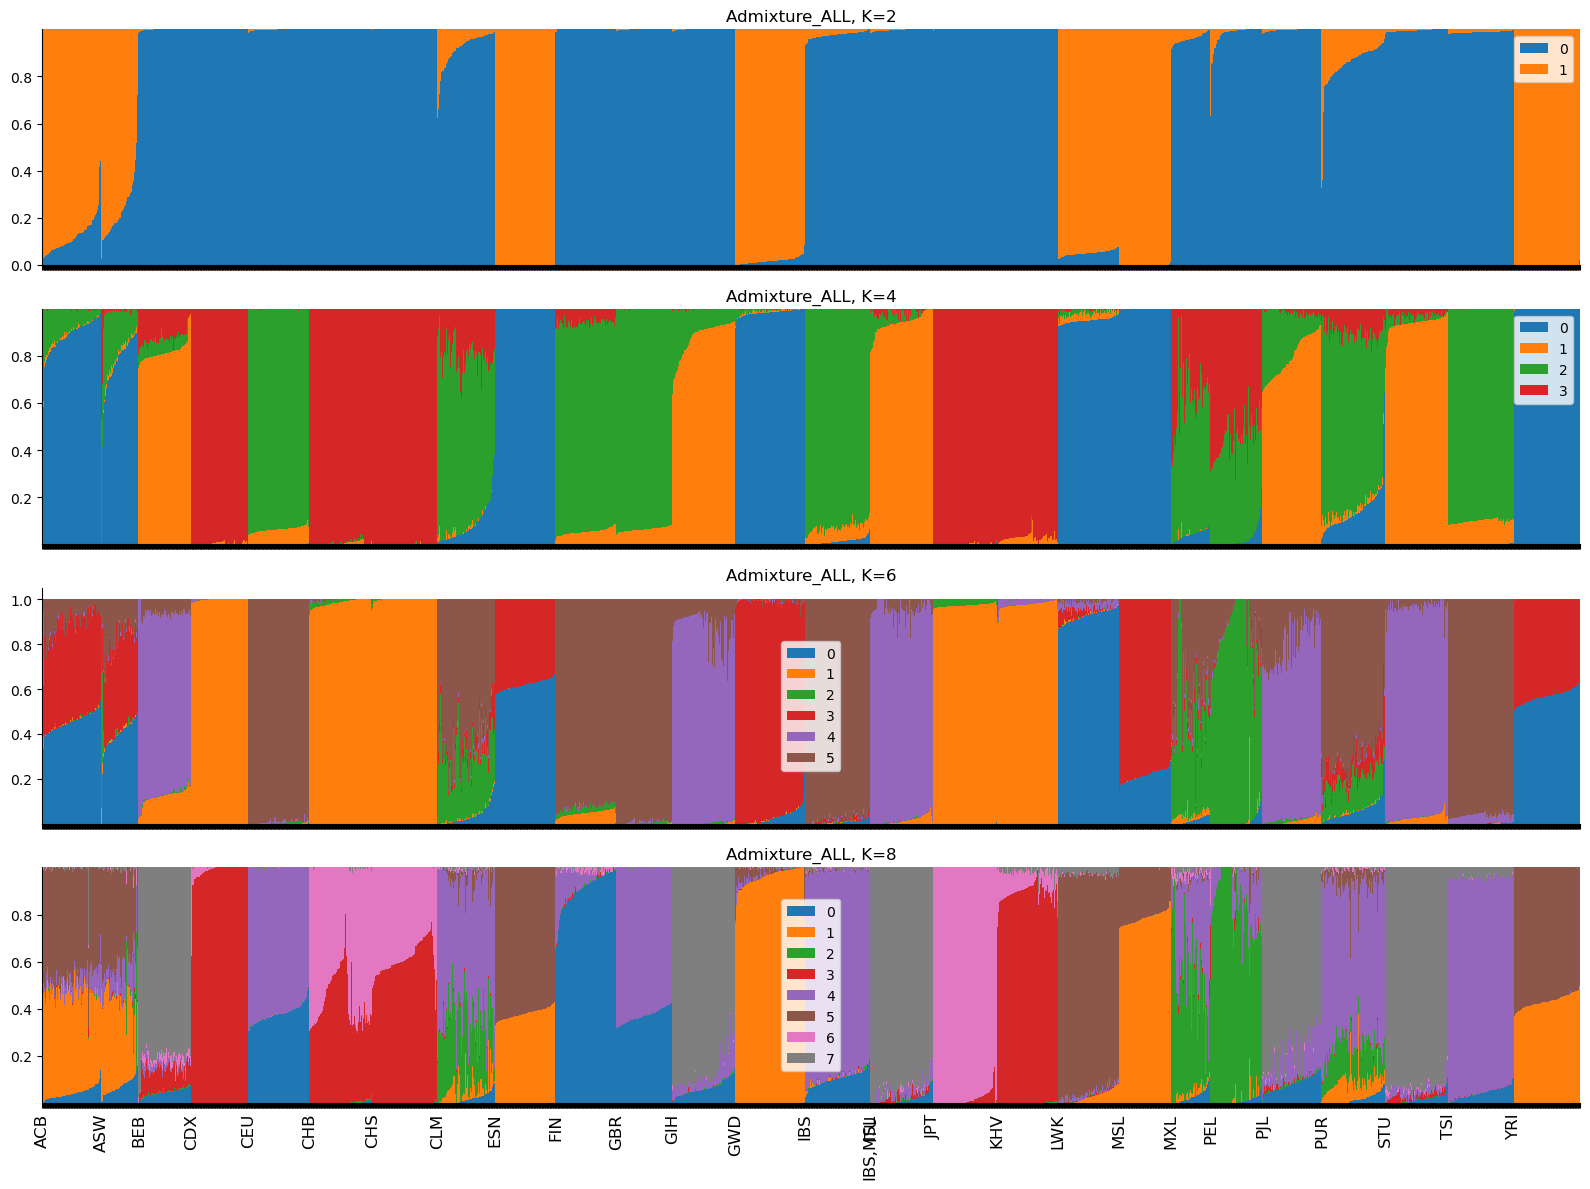

In [7]:

import pandas as pd
import os
import matplotlib.pyplot as plt

sampleinfo = pd.read_csv("1000Genomes/igsr_samples.tsv", sep="\t")
sample_to_pop = dict(zip(list(sampleinfo["Sample name"]), list(sampleinfo["Population code"])))
samples = [line.split()[0] for line in open("dump/admixture/admixture_ALL.pruned.fam", "r").readlines()]
pops = [sample_to_pop.get(item, "NA") for item in samples]

fig = plt.figure()
fig.set_size_inches((16, 12))

plotind = 1
k_list = [2,4,6,8]
for K in k_list:
    ax = fig.add_subplot(len(k_list), 1, plotind)

    data = pd.read_csv("dump/admixture/admixture_ALL.pruned.%s.Q" % K, sep=r"\s+", header=None)
    cols = list(data.columns)
    data["sample"] = samples
    data["pop"] = pops
    data = data.sort_values(["pop"] + cols)
    data[cols].plot.bar(stacked=True, ax=ax, width=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    # Only plot label for first sample in each pop
    xticklabels = []
    currpop = ""
    for i in range(data.shape[0]):
        if data["pop"].values[i] == currpop:
            xticklabels.append("")
        else:
            xticklabels.append(data["pop"].values[i])
            currpop = data["pop"].values[i]
    if plotind < len(k_list):
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=12)
    ax.set_title(f"Admixture_ALL, K={K}")

    plotind += 1
fig.tight_layout()


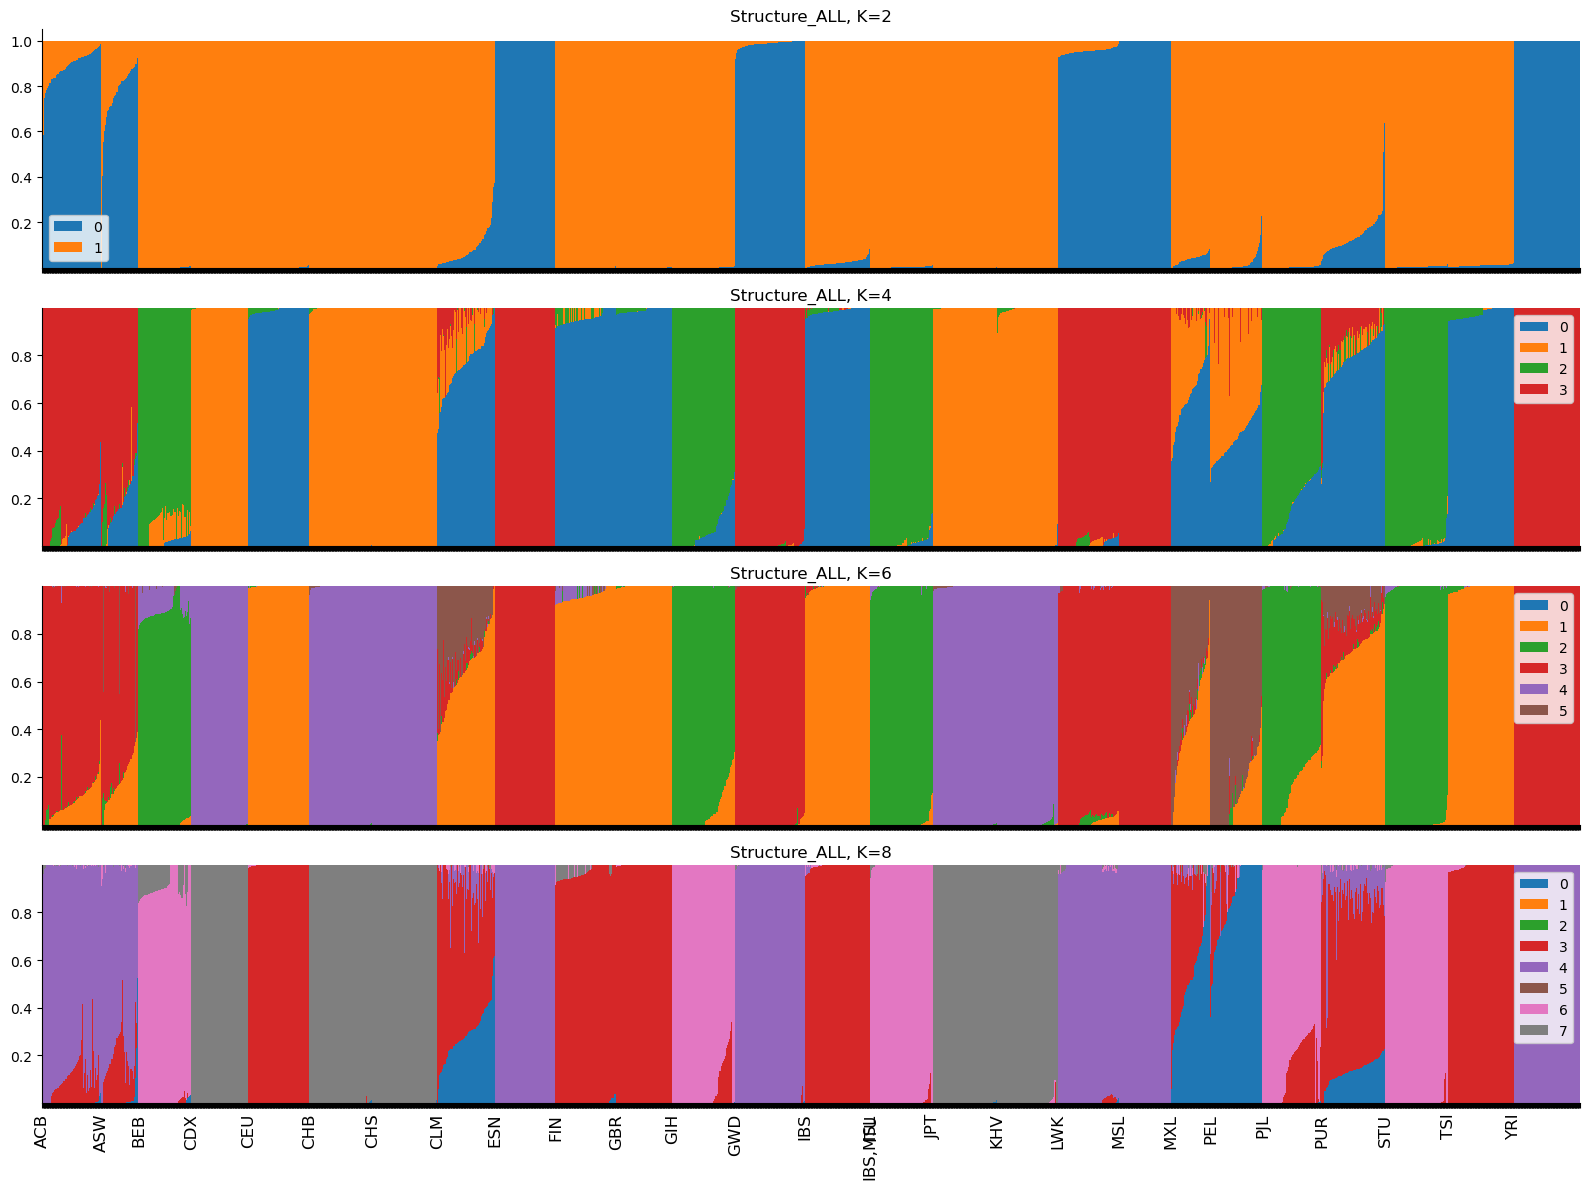

In [8]:

import pandas as pd
import os
import matplotlib.pyplot as plt
sampleinfo = pd.read_csv("1000Genomes/igsr_samples.tsv", sep="\t")
sample_to_pop = dict(zip(list(sampleinfo["Sample name"]), list(sampleinfo["Population code"])))
samples = [line.split()[0] for line in open("dump/structure/structure_ALL.pruned.fam", "r").readlines()]
pops = [sample_to_pop.get(item, "NA") for item in samples]

fig = plt.figure()
fig.set_size_inches((16, 12))

plotind = 1
k_list = [2,4,6,8]
for K in k_list:
    ax = fig.add_subplot(len(k_list), 1, plotind)

    data = pd.read_csv("dump/structure/structure_ALL/fS_run_K.%s.meanQ" % K, sep=r"\s+", header=None)
    cols = list(data.columns)
    data["sample"] = samples
    data["pop"] = pops
    data = data.sort_values(["pop"] + cols)
    data[cols].plot.bar(stacked=True, ax=ax, width=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    # Only plot label for first sample in each pop
    xticklabels = []
    currpop = ""
    for i in range(data.shape[0]):
        if data["pop"].values[i] == currpop:
            xticklabels.append("")
        else:
            xticklabels.append(data["pop"].values[i])
            currpop = data["pop"].values[i]
    if plotind < len(k_list):
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=12)
    ax.set_title(f"Structure_ALL, K={K}")

    plotind += 1
fig.tight_layout()


## Quantitative Comparison on Global Ancestry Inference Results

### K-value Evaluation

To determine the optimal number of ancestral populations ($K$), we evaluated two different metrics across a range of $K$ values (from 2 to 10). Choosing the "right" $K$ involves identifying the point where model fit improves significantly before hitting diminishing returns.

#### Methodology and Metrics
- ADMIXTURE (Cross-Validation Error): 
We utilized 10-fold cross-validation. In this metric, a lower CV error indicates a better-supported $K$ value, as it suggests the model has better predictive power.
- fastSTRUCTURE (Marginal Likelihood): We measured the model's marginal likelihood. In this case, a higher (less negative) value indicates a more probable $K$ for the given dataset.

#### Results and Interpretation
Based on the generated plots, we observed the following:

- ADMIXTURE: The CV error decreases sharply from $K=2$ to $K=5$. After $K=5$, the rate of decrease slows down significantly, suggesting that additional clusters beyond this point add marginal explanatory power.

- fastSTRUCTURE: The marginal likelihood shows an evident peak and "elbow" at $K=5/6$.

Based on the combined evidence from both tools—specifically the sharp decline in CV error and the plateau in marginal likelihood—we have selected $K = 4, 5, 6, \text{and } 7$ as the candidate values for further population structure analysis. 
<!-- These values capture the primary levels of genetic differentiation without over-partitioning the data. -->

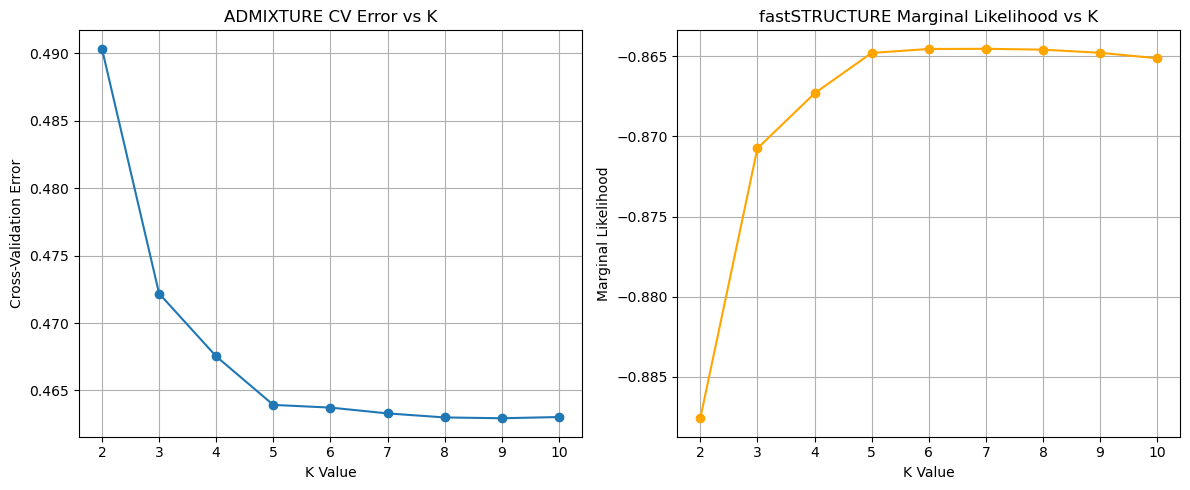

In [ ]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

repo = Path.cwd()

# Load ADMIXTURE CV errors from output file
cv_path = repo / "dump" / "admixture" / "cv_results.txt"
cv_pairs = []
for line in cv_path.read_text().strip().splitlines():
    k_str, cv_str = line.split()
    cv_pairs.append((int(k_str), float(cv_str)))
cv_pairs.sort(key=lambda x: x[0])


def extract_marginal_likelihood(log_path: Path) -> float:
    text = log_path.read_text()
    match = re.search(r"Marginal Likelihood =\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", text)
    if match is None:
        raise ValueError(f"Cannot find marginal likelihood in {log_path}")
    return float(match.group(1))


# Load fastSTRUCTURE marginal likelihoods from per-K logs
ml_pairs = []
for k, _ in cv_pairs:
    log_path = repo / "dump" / "structure" / "structure_ALL" / f"fS_run_K.{k}.log"
    ml_pairs.append((k, extract_marginal_likelihood(log_path)))

k_values = [k for k, _ in cv_pairs]
cv_errors = [value for _, value in cv_pairs]
ml = [value for _, value in ml_pairs]

# Create two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- Subplot 1: ADMIXTURE CV error -----
axes[0].plot(k_values, cv_errors, marker='o')
axes[0].set_xlabel("K Value")
axes[0].set_ylabel("Cross-Validation Error")
axes[0].set_title("ADMIXTURE CV Error vs K")
axes[0].set_xticks(k_values)
axes[0].grid(True)

# ----- Subplot 2: fastSTRUCTURE Marginal Likelihood -----
axes[1].plot(k_values, ml, marker='o', color='orange')
axes[1].set_xlabel("K Value")
axes[1].set_ylabel("Marginal Likelihood")
axes[1].set_title("fastSTRUCTURE Marginal Likelihood vs K")
axes[1].set_xticks(k_values)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Superpopulation Hard Classification

The 1000 Genomes project provides 5 **superpopulation labels** (AFR / AMR / EAS / EUR / SAS) for each individual. Although they are not mixture proportion continuous ground truths, they serve as an external reference for evaluating whether the inferred ancestry assignment is consistent with known population structure.

**Approach:**

0. Consider K = 5 as there are 5 superpopulations.
1. For each individual $i$, take the *hard assignment* $\hat{k}_i = \arg\max_k Q_{ik}$.
2. For each component $k$, identify its plurality superpopulation (the super-pop most common among individuals whose hard assignment is $k$).
3. Map each individual's hard-assignment component to its plurality superpopulation label and compare against the real superpopulation label.
4. Report **accuracy** and **macro-F1** only.

In [22]:

import re
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

SUPER_POPS = ["AFR", "AMR", "EAS", "EUR", "SAS"]
K = 5

_SPLIT = re.compile(r"[,\|;/\s]+")

def parse_superpops(x):
    if x is None or pd.isna(x):
        return []
    parts = [p.strip() for p in _SPLIT.split(str(x).strip()) if p.strip()]
    out = [p for p in parts if p in SUPER_POPS]
    seen, out2 = set(), []
    for p in out:
        if p not in seen:
            out2.append(p); seen.add(p)
    return out2

def hard_assign(Q):
    return np.argmax(Q, axis=1)

def component_to_superpop_multilabel(assignments, true_sets, K):
    comp_map = {}
    for k in range(K):
        m = (assignments == k)
        if not np.any(m):
            comp_map[k] = "NA"
            continue
        counts = pd.Series(0, index=SUPER_POPS, dtype=int)
        for labs in np.array(true_sets, dtype=object)[m]:
            for sp in labs:
                counts[sp] += 1
        comp_map[k] = counts.idxmax() if counts.sum() > 0 else "NA"
    return comp_map

def multilabel_crosstab(true_sets, y_pred):
    rows = []
    for s, pred in zip(true_sets, y_pred):
        for sp in s:
            rows.append((sp, pred))
    df = pd.DataFrame(rows, columns=["True", "Predicted"])
    return pd.crosstab(df["True"], df["Predicted"])

def evaluate_superpop_multilabel(Q, superpops_list, K=5):
    labels_raw = np.asarray(superpops_list, dtype=object)
    true_sets = [parse_superpops(x) for x in labels_raw]
    valid = np.array([len(s) > 0 for s in true_sets], dtype=bool)

    Qv = np.asarray(Q, float)[valid]
    true_sets_v = np.array(true_sets, dtype=object)[valid]

    assigns = hard_assign(Qv)
    comp_map = component_to_superpop_multilabel(assigns, true_sets_v, K)
    y_pred = np.array([comp_map.get(a, "NA") for a in assigns], dtype=object)

    acc = float(np.mean([pred in s for pred, s in zip(y_pred, true_sets_v)]))

    sp_to_idx = {sp: i for i, sp in enumerate(SUPER_POPS)}
    Y_true = np.zeros((len(true_sets_v), len(SUPER_POPS)), dtype=int)
    for i, s in enumerate(true_sets_v):
        for sp in s:
            Y_true[i, sp_to_idx[sp]] = 1

    Y_pred = np.zeros_like(Y_true)
    for i, pred in enumerate(y_pred):
        j = sp_to_idx.get(pred)
        if j is not None:
            Y_pred[i, j] = 1

    macro_f1 = f1_score(Y_true, Y_pred, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_F1": macro_f1}, comp_map, true_sets_v, y_pred

# ---- K=5 only ----
for name, Q in [("ADMIXTURE", adm_Q[5]), ("fastSTRUCTURE", fst_Q[5])]:
    metrics, comp_map, true_sets_v, y_pred = evaluate_superpop_multilabel(Q, superpops, K=5)
    print(f"\n{name} hard-assignment metrics (K=5, multi-label truth): {metrics}")
    print(f"{name} component->superpop mapping:", comp_map)
    print(f"{name} multi-label crosstab:")
    display(multilabel_crosstab(true_sets_v, y_pred))


ADMIXTURE hard-assignment metrics (K=5, multi-label truth): {'accuracy': 0.9105431309904153, 'macro_F1': 0.8692602640064113}
ADMIXTURE component->superpop mapping: {0: 'EUR', 1: 'AMR', 2: 'SAS', 3: 'AFR', 4: 'EAS'}
ADMIXTURE multi-label crosstab:


Predicted,AFR,AMR,EAS,EUR,SAS
True,,,,,
AFR,658,2,0,2,0
AMR,5,126,0,216,0
EAS,0,0,504,0,0
EUR,0,0,0,503,0
SAS,0,0,0,0,489



fastSTRUCTURE hard-assignment metrics (K=5, multi-label truth): {'accuracy': 0.9093450479233227, 'macro_F1': 0.8673055710682334}
fastSTRUCTURE component->superpop mapping: {0: 'AMR', 1: 'SAS', 2: 'EUR', 3: 'AFR', 4: 'EAS'}
fastSTRUCTURE multi-label crosstab:


Predicted,AFR,AMR,EAS,EUR,SAS
True,,,,,
AFR,657,3,0,2,0
AMR,5,124,0,217,1
EAS,0,0,504,0,0
EUR,0,0,0,503,0
SAS,0,0,0,0,489


### Superpopulation Soft Classification

Rather than collapsing $Q$ to a hard label, we can treat each individual's ancestry proportion vector as a **soft probability assignment** over the $K$ inferred components and evaluate how faithfully it captures the known superpopulation label using the multi-class Brier Score:

$$\text{BS} = \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} \left( \hat{p}_{ik} - y_{ik} \right)^2 $$

where $y_{ik} \in \{0,1\}$ is the one-hot superpopulation indicator and $\hat{p}_{ik}$ is the ancestry proportion assigned to the component that was matched (via plurality mapping) to superpopulation $k$.

A lower Brier Score means the soft output is better calibrated to the known superpopulation labels. This provides a stricter assessment because it rewards confident correct predictions and penalises uncertain or wrong ones.

In [23]:
K = 5
EPS = 1e-12

def build_Q5_Y_multilabel(Q, superpops_list, K=5):
    labels_raw = np.asarray(superpops_list, dtype=object)
    true_sets = [parse_superpops(x) for x in labels_raw]
    valid = np.array([len(s) > 0 for s in true_sets], dtype=bool)

    Qv = np.asarray(Q, float)[valid]
    Qv = np.clip(Qv, EPS, None)
    Qv /= Qv.sum(axis=1, keepdims=True)

    true_sets_v = np.array(true_sets, dtype=object)[valid]
    assigns = hard_assign(Qv)
    comp_map = component_to_superpop_multilabel(assigns, true_sets_v, K)

    sp_to_idx = {sp: i for i, sp in enumerate(SUPER_POPS)}

    Q5 = np.zeros((len(true_sets_v), len(SUPER_POPS)), dtype=float)
    for k, sp in comp_map.items():
        j = sp_to_idx.get(sp)
        if j is not None:
            Q5[:, j] += Qv[:, k]

    rs = Q5.sum(axis=1, keepdims=True)
    Q5 /= np.where(rs == 0, 1.0, rs)

    Y = np.zeros_like(Q5)
    for i, s in enumerate(true_sets_v):
        w = 1.0 / len(s)
        for sp in s:
            Y[i, sp_to_idx[sp]] += w

    return Q5, Y, comp_map

def brier(Q5, Y):
    return ((Q5 - Y) ** 2).sum(axis=1).mean()

def per_superpop_brier(Q5, Y):
    out = {}
    for j, sp in enumerate(SUPER_POPS):
        m = Y[:, j] > 0
        out[sp] = ((Q5[m] - Y[m]) ** 2).sum(axis=1).mean() if np.any(m) else np.nan
    return out

def eval_brier_K5(Q, labels):
    Q5, Y, comp_map = build_Q5_Y_multilabel(Q, labels, K=5)
    return brier(Q5, Y), per_superpop_brier(Q5, Y), comp_map

# ---- K=5 only ----
adm_overall, adm_sp, adm_map = eval_brier_K5(adm_Q[5], superpops)
fst_overall, fst_sp, fst_map = eval_brier_K5(fst_Q[5], superpops)

print("\nBrier (K=5, multi-label truth as uniform distribution over labels):")
display(pd.DataFrame([{
    "K": 5,
    "ADMIXTURE": adm_overall,
    "fastSTRUCTURE": fst_overall
}]).round(5).set_index("K"))

print("\nComponent->superpop mapping (multi-label voting):")
print("ADMIXTURE:", adm_map)
print("fastSTRUCTURE:", fst_map)

sp_df = pd.DataFrame({
    "Super-pop": SUPER_POPS,
    "ADMIXTURE": [adm_sp[sp] for sp in SUPER_POPS],
    "fastSTRUCTURE": [fst_sp[sp] for sp in SUPER_POPS],
}).round(5).set_index("Super-pop")
print("\nPer-super-pop Brier (multi-label samples contribute to every class they contain):")
display(sp_df)


Brier (K=5, multi-label truth as uniform distribution over labels):


,ADMIXTURE,fastSTRUCTURE
K,,
5,0.11971,0.12735



Component->superpop mapping (multi-label voting):
ADMIXTURE: {0: 'EUR', 1: 'AMR', 2: 'SAS', 3: 'AFR', 4: 'EAS'}
fastSTRUCTURE: {0: 'AMR', 1: 'SAS', 2: 'EUR', 3: 'AFR', 4: 'EAS'}

Per-super-pop Brier (multi-label samples contribute to every class they contain):


,ADMIXTURE,fastSTRUCTURE
Super-pop,,
AFR,0.01974,0.01746
AMR,0.76120,0.85004
EAS,0.00085,0.00008
EUR,0.00366,0.00133
SAS,0.04240,0.02486
